In [ ]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, BisectingKMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
import scipy
from kneed import KneeLocator
from typing import Tuple, Literal, Any
import scipy.stats as stats
from gensim.models import KeyedVectors
import re
from mpl_toolkits.mplot3d import Axes3D 
import matplotlib as mpl
from cycler import cycler


In [ ]:
mpl.rcParams['axes.prop_cycle'] = cycler(color=['teal', 'maroon', '#3EB489', '#6B8E23'])

In [ ]:
df = pd.read_csv('/home/uplong/Downloads/DSU-Dataset.csv', parse_dates=['Date'], dtype={'Hour':'int32'})
display(df)
df.dtypes

In [ ]:
display(df.isna().sum())

In [ ]:
df.describe()

In [ ]:
df['ED Enc Admitted'].sum() / df['ED Enc'].sum() # admittance rate

In [ ]:
# Minor preprossesing that will be useful for later
df.fillna('NaN', inplace=True)

def remove_special_characters(text:str) -> str:
    return re.sub(r"[^a-zA-Z0-9 ]", "  ", text)

def replace_covid(text:str) -> str:
    return re.sub('COVID', 'CORONOVIRUS', text)

df['REASON_VISIT_NAME'] = df['REASON_VISIT_NAME'].apply(remove_special_characters).apply(replace_covid)

## Reason of encounter analysis

In [ ]:
unique_reasons = df['REASON_VISIT_NAME'].unique()
unique_reasons.sort()
unique_reasons, unique_reasons.shape

In [ ]:
reason_count = (
    df.groupby('REASON_VISIT_NAME')
      .agg(
          total_occurences_of_reason=('REASON_VISIT_NAME', 'size'),
          total_visits=('ED Enc', 'sum'),
          total_admitted=('ED Enc Admitted', 'sum')
      )
      .sort_values(by='total_visits', ascending=False)
)
reason_count['percentage_of_admittance'] = (reason_count['total_admitted'] / reason_count['total_visits'])*100
display(reason_count)
reason_count.describe()

In [ ]:
COVID_df = reason_count[(reason_count['percentage_of_admittance']>50) & (reason_count['total_visits']>50)].sort_values(by='total_occurences_of_reason', ascending=True)

In [ ]:
COVID_df['percentage_of_admittance'].plot(kind='bar', figsize=(20,10))

## Date/Time analysis

In [ ]:
grouped_by_year = df.groupby(by = df['Date'].dt.year).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_year.plot(kind='bar', figsize=(10,6), xlabel='Year')

In [ ]:
# Check what happend in Covid peak
df[(df['Date'].dt.year == 2020) & (df['Date'].dt.month >= 3) & (df['Date'].dt.month <= 6)].groupby(by='REASON_VISIT_NAME').agg('size').sort_values(ascending=False)

In [ ]:
grouped_by_year_month = df.groupby(by = [df['Date'].dt.year, df['Date'].dt.month]).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
# for i in range(2018,2026):
#     grouped_by_year.loc[i].plot.bar()

ax1 = grouped_by_year_month['unique_entry_per_day'].plot(kind='barh', figsize = (6,20), xlabel='Year/Month', xlim=8000, grid=True)
ax1.invert_yaxis()
ax1.tick_params(top=True, labeltop=True)
plt.show()
ax2 = grouped_by_year_month['unique_entry_per_day'].plot(kind='line', figsize = (20,10), xlabel='Year/Month', xlim=0)
plt.show()



In [ ]:
grouped_by_month = df.groupby(by = df['Date'].dt.month).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_month.plot(kind='bar', figsize = (10,8), xlabel='Month')

In [ ]:
grouped_by_day = df.groupby(by = df['Date'].dt.day).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day.plot(kind='bar', figsize = (20,8), xlabel='Day of the month')

In [ ]:
grouped_by_day_of_week = df.groupby(by = df['Date'].dt.day_of_week).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )

grouped_by_day_of_week.plot(kind='bar', figsize = (10,8), xlabel='Day of the week')

In [ ]:
grouped_by_year_reasons = df.groupby(by = [df['Date'].dt.year, df['REASON_VISIT_NAME']]).agg('size')
grouped_by_year_reasons = grouped_by_year_reasons.reset_index()
display(grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500)],
        grouped_by_year_reasons[(grouped_by_year_reasons[0] > 500) & (grouped_by_year_reasons['REASON_VISIT_NAME']=='ALLERGIC REACTION')]
)

Since there is no much insight in direct date analysis, lets try to see if there are any "seasonal illnesses"

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))  
axes = axes.flatten() 

years = range(2018, 2026) 

for idx, j in enumerate(years):
    df_year = df[df['Date'].dt.year == j]
    test = df_year.groupby([df_year['Date'].dt.month, df_year['REASON_VISIT_NAME']]).size()

    count_of_reasons_per_month = [test.loc[i].sum() if i in test.index.levels[0] else 0 for i in range(1, 13)]

    axes[idx].bar(range(1, 13), count_of_reasons_per_month)
    axes[idx].set_title(f"Year {j}")
    # axes[idx].set_xlabel("Month")
    # axes[idx].set_ylabel("Count")

for ax in axes[len(years):]:
    fig.delaxes(ax)

fig.text(0.5, 0.04, 'Month', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Count', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()


In [ ]:
test = df[df['Date'].dt.year==2022].groupby(by=[df['Date'].dt.month, df['REASON_VISIT_NAME']])['REASON_VISIT_NAME'].apply('size').to_frame()
test2 = test.rename(columns={'REASON_VISIT_NAME':'count_of_reason'}).reset_index()
test2[test2['count_of_reason']>500]

In [ ]:
grouped_by_time = df.groupby(by = df['Hour']).agg(
    unique_entry_per_day = ('Date', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_time['admitance_rate'] = grouped_by_time['total_admittances'] / grouped_by_time['total_encounters']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns
grouped_by_time.iloc[:,:-1].plot(kind='bar', xlabel='Hour', ylim=grouped_by_time.iloc[:,:-1].min()['total_admittances'], ax=axes[0])
grouped_by_time['admitance_rate'].plot(kind='bar', ylim=grouped_by_time['admitance_rate'].min(), ax=axes[1])
plt.show()


## Analysis by site

In [ ]:
grouped_by_site = df.groupby(by='Site').agg(
    site = ('Site', 'size'),
    total_encounters = ('ED Enc', 'sum'),
    total_admittances = ('ED Enc Admitted', 'sum')
    )
grouped_by_site['admittance_rate'] = grouped_by_site['total_admittances'] /grouped_by_site['total_encounters']
display(grouped_by_site)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns
grouped_by_site.iloc[:,:-1].plot(kind='bar', ax=axes[0]) # finally some sort of imbalance
grouped_by_site['admittance_rate'].plot(kind='bar', ax=axes[1], legend=True, color='maroon')
plt.show()

## Misc

Why would 'ED Enc' and 'ED Enc Admitted' take values > 1 ?

In [ ]:
df[df['ED Enc']>1].shape[0] / df.shape[0] # only 7%

In [ ]:
df[df['ED Enc Admitted']>1].shape[0] / df.shape[0]

# Syndromic Grouping 

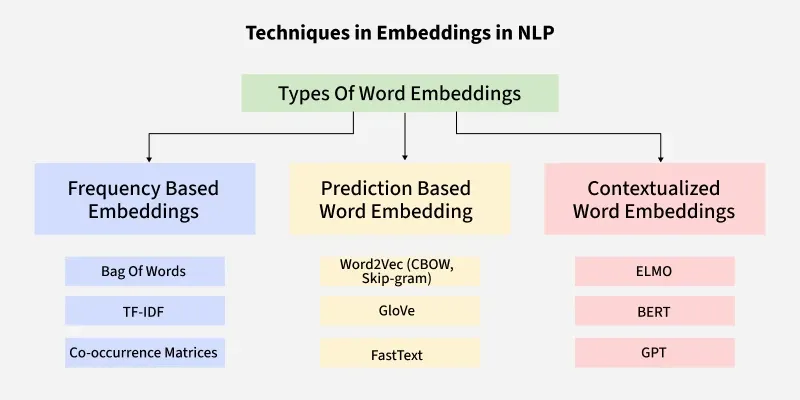

* Vectorizers: TF-IDF, W2V
* Clustering algorithms: K-Means

* Note, up to discussion: should cluster based on semantic or textual similarity? If we want semantic we need to normalize, to make the Euclidean distance equivalent to the cosine similarity.

## TF-IDF

In [ ]:
unique_reasons

In [ ]:
vectorizer = TfidfVectorizer(ngram_range=(1,2), lowercase=False)

X = vectorizer.fit_transform(unique_reasons) # return a sparse matrix where row -> reason, column -> embedding vector
vectorizer.get_feature_names_out().tolist()[:15]

In [ ]:
X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()

In [ ]:
unique_reasons[X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()]

In [ ]:
idxs_of_keyword = X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()
idxs_of_keyword

In [ ]:
vectorizer.vocabulary_['BREATHING PROBLEM']

In [ ]:
unique_reasons_containing_keyword = unique_reasons[X[:,vectorizer.vocabulary_['BREATHING PROBLEM']].toarray().flatten().nonzero()]
unique_reasons_containing_keyword

## BioWordVec
https://github.com/ncbi-nlp/BioSentVec?tab=readme-ov-file#biowordvec

In [ ]:
# MODEL_PATH = "BioWordVec_PubMed_MIMICIII_d200.vec.bin"

# bwv = KeyedVectors.load_word2vec_format(MODEL_PATH, binary=True, limit=int(3e6))

In [ ]:
# def sentence_vector(text: str) -> np.ndarray:
#     tokens = text.lower().split()
#     vectors = [bwv[word] for word in tokens if word in bwv]

#     if not vectors:
#         # return np.zeros(200, dtype=np.float32)
#         return 0

#     return np.mean(vectors, axis=0)

# embeddings = np.vstack([sentence_vector(t) for t in unique_reasons])
# print(embeddings.shape)

In [ ]:
# np.sum(embeddings == np.zeros(200))

In [ ]:
# # Sanity check: we are not missing any words from the model, which is due to preprocessing

# l=[]
# for r in unique_reasons:
#     tokens = r.lower().split()
#     check = l.extend([word for word in tokens if word not in bwv.key_to_index])

# l


In [ ]:
# X.shape, embeddings.shape

##### Basic Vectorization function

In [ ]:
def _sentence_vector(text: str, v: KeyedVectors) -> np.ndarray:
    tokens = text.lower().split()
    vectors = [v[word] for word in tokens if word in v]

    if not vectors:
        return np.zeros(200, dtype=np.float32)

    return np.mean(vectors, axis=0)

def _normalize(embeddings:np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    embeddings_normalized = embeddings / np.clip(norms, a_min=1e-12, a_max=None)
    return embeddings_normalized

def vectorize(data : np.ndarray, vectorizer : Literal['tf_idf', 'bio_word_vec'] = 'tf_idf', normalize:bool = False) -> Any:
    if vectorizer == 'tf_idf':
        v_ = TfidfVectorizer(ngram_range=(1,2), lowercase=False)
        embeddings = v_.fit_transform(data).toarray()
        return embeddings if not normalize else _normalize(embeddings)
    elif vectorizer == 'bio_word_vec':
        v_ = KeyedVectors.load_word2vec_format('BioWordVec_PubMed_MIMICIII_d200.vec.bin', binary=True, limit=int(3e6)) 
        embeddings = np.vstack([_sentence_vector(t, v_) for t in unique_reasons])
        return embeddings if not normalize else _normalize(embeddings)

## K-Means

In [ ]:
# Data for tf-idf 
e_t = vectorize(data=unique_reasons, vectorizer='tf_idf', normalize=True)

# Data for w2v
e_w = vectorize(data=unique_reasons, vectorizer='bio_word_vec', normalize=True)

In [ ]:
# model = KMeans(n_clusters=17, random_state=1) 
# model_weighted = KMeans(n_clusters=6, random_state=1) 
# model_w2v = KMeans(n_clusters=20, random_state=1)
# model_w2v_weighted = KMeans(n_clusters=5, random_state=1)


# pred_cluster = model.fit_predict(X) # UNWEIGHTED 
# pred_cluster_weighted = model_weighted.fit_predict(X, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist()) 
# pred_cluster_w2v = model_w2v.fit_predict(embeddings) # UNWEIGHTED 
# pred_cluster_weighted_w2v = model_w2v_weighted.fit_predict(embeddings, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist()) 

In [ ]:
# pred_cluster[idxs_of_keyword], pred_cluster_weighted[idxs_of_keyword] # We see that if the keyward cancer is included then they are all clustered together

In [ ]:
# pred_cluster_w2v[idxs_of_keyword], pred_cluster_weighted_w2v[idxs_of_keyword]

In [ ]:
# unique_reasons_containing_keyword[np.where(pred_cluster[idxs_of_keyword]!=4)]

##### Basic model function

In [ ]:
def kmeans_model(
        n_clusters:int,
        data:np.ndarray,
        weighted:bool | None = None,
        random_state:int = 1,
) -> np.ndarray:
    m = KMeans(n_clusters=n_clusters, random_state=random_state)
    if weighted:
        pc = m.fit(data) 
    else:
        pc = m.fit(data, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())  
    
    return pc

### Optimization of numbers of clusters

https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d

https://medium.com/@jeffzyme/understanding-inertia-distortion-and-silhouette-scores-and-their-differences-key-metrics-for-458fe28ce2aa

Three "standard" measures for analysis of clustering algorithms:
* **Inertia:** Measures the compactness of the clusters i.e. how close the points of each cluster is to their respective centroid. 
$$\text{INERTIA} =\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert^2$$
It’s particularly useful in the Elbow Method when combined with distortion.

* **Distortion:** Lower distortion scores suggest points are tightly grouped, but too many clusters may imply overfitting. 
$$\text{Distortion Score} = \frac{1}{N}\sum_{C\in\text{CLUSTERS}} \, \sum_{x\in C}\Vert x-\text{centroid}(C)\Vert$$

* **Silhouette:** High average silhouette scores across all points suggest strong clustering, with distinct separation between clusters. This score is particularly insightful for comparing different clustering approaches, as it evaluates both within-cluster tightness and inter-cluster separation. For $x\in C$
$$\text{Silhouette Score}=\frac{b-a}{\max(a,b)}$$
 where $a$ is the average distance of $x$ to every other point in its cluster and $b$ is the average from all the points to the neighboring cluster (i.e. the cluster with the closer centroid).

The overall Silhouette Score is the average of silhouette scores for all points, producing a range from −1 to 1:

*    Values close to 1 indicate well-separated clusters,
*    Values near 0 suggest overlapping clusters,
*    Negative values signal possible misclassification.

In [ ]:
def distortion_score(model: KMeans | BisectingKMeans, X: np.ndarray | scipy.sparse._csr.csr_matrix) -> float:
    labels = model.labels_
    centers = model.cluster_centers_
    N = X.shape[0]
    ds = 1/N * np.linalg.norm((X.toarray() - centers[labels])) if type(X) == scipy.sparse._csr.csr_matrix else 1/N * np.linalg.norm((X - centers[labels]))
    return ds

In [ ]:
def find_elbow(
        clusters_upper_bound:int,
        data: np.ndarray,
        weighted:bool | None = None,
        random_state:int = 1,
        model_type:str = Literal['kmeans', 'bkmeans'],
) -> int:
    
    ks = range(2, clusters_upper_bound, 1)
    inertias = []
    distortions = []
    silhouettes = []

    for k in ks:
        if model_type =='kmeans':
            model = KMeans(n_clusters=k, random_state=random_state)
        elif model_type =='bkmeans':
            model = BisectingKMeans(n_clusters=k, random_state=random_state)        
        if weighted:
            model.fit(data, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())
        else:
            model.fit(data)

        inertias.append(model.inertia_)
        distortions.append(distortion_score(model, data))
        silhouettes.append( silhouette_score(data, model.predict(data)) )

    kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # Inertia
    axes[0].plot(ks, inertias, '-o', color='blue')
    axes[0].set_title('Inertia')
    axes[0].set_xlabel('k')
    axes[0].set_ylabel('Inertia')

    # Distortion
    axes[1].plot(ks, distortions, '-o', color='red')
    axes[1].set_title('Distortion')
    axes[1].set_xlabel('k')
    axes[1].set_ylabel('Distortion')

    # Silhouette
    axes[2].plot(ks, silhouettes, '-o', color='green')
    axes[2].set_title('Silhouette Score')
    axes[2].set_xlabel('k')
    axes[2].set_ylabel('Score')

    # Knee lines (only where meaningful)
    for ax in axes:
        for k in kn.all_knees:
            ax.axvline(k, linestyle='--', color='black')

    plt.tight_layout()
    plt.show()

    return kn.knee
    

In [ ]:
# Optimal number of clusters for unweighted, tf-idf, kmeans model
k1 = find_elbow(clusters_upper_bound=50, data=e_t, model_type='kmeans')

# Optimal number of clusters for weighted, tf-idf, kmeans model
k2 = find_elbow(clusters_upper_bound=50, data=e_t, weighted=True, model_type='kmeans')

# Optimal number of cluster for unweighted, w2v, kmeans model
k3 = find_elbow(clusters_upper_bound=50, data=e_w, model_type='kmeans')

# Optimal number of cluster for weighted, w2v, kmeans model
k4 = find_elbow(clusters_upper_bound=50, data=e_w, weighted=True, model_type='kmeans')

In [ ]:
k1, k2, k3, k4

In [ ]:
# # Opt. for unweighted K-Means with TF-IDF

# ks = range(2, 50, 1)
# inertias = []
# distortions = []
# silhouettes = []

# for k in ks:
#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(X)
#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, X))
#     silhouettes.append( silhouette_score(X, model.predict(X)) )

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()

In [ ]:
# kn.knee

In [ ]:
# # Opt. for weighted K-Means with TF-IDF

# ks = range(2, 50, 1)
# inertias = []
# distortions = []
# silhouettes = []

# for k in ks:

#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(X, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())
#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, X))
#     silhouettes.append( silhouette_score(X, model.predict(X)) )

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()

In [ ]:
# kn.all_knees

In [ ]:
# # Opt. for unweighted K-Means with w2v

# ks = range(2, 50, 1)
# inertias = []
# distortions = []
# silhouettes = []

# for k in ks:

#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(embeddings)
#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, embeddings))
#     silhouettes.append( silhouette_score(embeddings, model.predict(embeddings)) )

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()

In [ ]:
# kn.knee

In [ ]:
# find_elbow(50, embeddings, True, 1)

In [ ]:
# # Opt. for weighted K-Means with w2v

# ks = range(2, 50)
# inertias = []
# distortions = []
# silhouettes = []

# weights = reason_count.sort_index()['total_occurences_of_reason'].to_numpy()

# for k in ks:
#     model = KMeans(n_clusters=k, random_state=1)
#     model.fit(embeddings, sample_weight=weights)

#     inertias.append(model.inertia_)
#     distortions.append(distortion_score(model, embeddings))
#     silhouettes.append(silhouette_score(embeddings, model.labels_))

# kn = KneeLocator(ks, distortions, curve='convex', direction='decreasing')

# fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# # Inertia
# axes[0].plot(ks, inertias, '-o')
# axes[0].set_title('Inertia')
# axes[0].set_xlabel('k')
# axes[0].set_ylabel('Inertia')

# # Distortion
# axes[1].plot(ks, distortions, '-o')
# axes[1].set_title('Distortion')
# axes[1].set_xlabel('k')
# axes[1].set_ylabel('Distortion')

# # Silhouette
# axes[2].plot(ks, silhouettes, '-o')
# axes[2].set_title('Silhouette Score')
# axes[2].set_xlabel('k')
# axes[2].set_ylabel('Score')

# # Knee lines (only where meaningful)
# for ax in axes:
#     for k in kn.all_knees:
#         ax.axvline(k, linestyle='--', color='black')

# plt.tight_layout()
# plt.show()


In [ ]:
# kn.all_knees

### Qualitative analysis on the cluster-optimized K-means model.

In [ ]:
# Models 

# Unweighted, tf-idf, kmeans
m1 = kmeans_model(n_clusters=k1, data=e_t)

# Weighted, tf-idf, kmeans
m2 = kmeans_model(n_clusters=k2, data=e_t, weighted=True)

# Unweighted, w2v, kmeans
m3 = kmeans_model(n_clusters=k3, data=e_w)

# Weighted, w2v, kmeans
m4 = kmeans_model(n_clusters=k4, data=e_w, weighted=True)

In [ ]:
def remap(reason:str, model, data: np.ndarray) -> int:
    '''
    Input:
        str - the reason of the encounter 
    Output:
        Tuple[int, int] - the corresponding cluster of the unweighted and weighted models respectively
    '''
    idx_of_reason = np.where(reason == unique_reasons)
    return model.predict(data[idx_of_reason])[0]

# remap('ABDOMINAL PAIN', model=model, model_weighted=model_weighted)


In [ ]:
unique_vals = df["REASON_VISIT_NAME"].unique()
unique_vals

In [ ]:
# Include the clustering to the df
unique_vals = df["REASON_VISIT_NAME"].unique()

r1 = {val: remap(val, m1, e_t) for val in unique_vals}
r2 = {val: remap(val, m2, e_t) for val in unique_vals}
r3 = {val: remap(val, m3, e_w) for val in unique_vals}
r4 = {val: remap(val, m4, e_w) for val in unique_vals}

df["td-idf"] = df["REASON_VISIT_NAME"].map(r1)
df["weighted_td-idf"] = df["REASON_VISIT_NAME"].map(r2)
df["w2v"] = df["REASON_VISIT_NAME"].map(r3)
df["w2v_weighted"] = df["REASON_VISIT_NAME"].map(r4)

In [ ]:
df

In [ ]:
grouped_by_UM_clusters = df.groupby(by='td-idf').agg('size')
grouped_by_WM_clusters = df.groupby(by='weighted_td-idf').agg('size')
grouped_by_UM_w2v_clusters = df.groupby(by='w2v').agg('size')
grouped_by_WM_w2v_clusters = df.groupby(by='w2v_weighted').agg('size')


In [ ]:
display(grouped_by_UM_clusters.describe())
display(grouped_by_WM_clusters.describe())
display(grouped_by_UM_w2v_clusters.describe())
display(grouped_by_WM_w2v_clusters.describe())

In [ ]:
mu1 = grouped_by_UM_clusters.mean()
sigma1 = grouped_by_UM_clusters.std()
variance1 = sigma1 ** 2

mu2 = grouped_by_WM_clusters.mean()
sigma2 = grouped_by_WM_clusters.std()
variance2 = sigma2 ** 2

mu3 = grouped_by_UM_w2v_clusters.mean()
sigma3 = grouped_by_UM_w2v_clusters.std()
variance1 = sigma3 ** 2

mu4 = grouped_by_WM_w2v_clusters.mean()
sigma4 = grouped_by_WM_w2v_clusters.std()
variance4 = sigma4 ** 2

x1 = np.linspace(mu1 - 3*sigma1, mu1 + 3*sigma1, 100)
x2 = np.linspace(mu2 - 3*sigma2, mu2 + 3*sigma2, 100)
x3 = np.linspace(mu3 - 3*sigma3, mu1 + 3*sigma3, 100)
x4 = np.linspace(mu4 - 3*sigma4, mu2 + 3*sigma4, 100)

plt.plot(x1, stats.norm.pdf(x1, mu1, sigma1), label='Unweighted clustering')
plt.plot(x2, stats.norm.pdf(x2, mu2, sigma2), label='Weighted clustering')
plt.plot(x3, stats.norm.pdf(x3, mu3, sigma3), label='Unweighted clustering W2V')
plt.plot(x4, stats.norm.pdf(x4, mu4, sigma4), label='Weighted clustering W2V')
plt.suptitle('KM')
plt.legend()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_UM_clusters.plot(kind='bar', ax=axes[0,0], title='TF-IDF | KM ', xlabel='')
grouped_by_WM_clusters.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted KM', xlabel='')

grouped_by_UM_w2v_clusters.plot(kind='bar', ax=axes[1,0], title='W2V | KM', xlabel='')
grouped_by_WM_w2v_clusters.plot(kind='bar', ax=axes[1,1], title='W2V | weighted KM', xlabel='')

fig.suptitle('Reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')
plt.tight_layout()
plt.show()

In [ ]:
grouped_by_UM_clusters_unique_reasons = df.groupby(by=['td-idf'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_UM_clusters_unique_reasons['count'] = grouped_by_UM_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_UM_clusters_unique_reasons

In [ ]:
grouped_by_WM_clusters_unique_reasons = df.groupby(by=['weighted_td-idf'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_WM_clusters_unique_reasons['count'] = grouped_by_WM_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_WM_clusters_unique_reasons

In [ ]:
grouped_by_UM_w2v_clusters_unique_reasons = df.groupby(by=['w2v'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_UM_w2v_clusters_unique_reasons['count'] = grouped_by_UM_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_UM_w2v_clusters_unique_reasons

In [ ]:
grouped_by_WM_w2v_clusters_unique_reasons = df.groupby(by=['w2v_weighted'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_WM_w2v_clusters_unique_reasons['count'] = grouped_by_WM_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_WM_w2v_clusters_unique_reasons

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_UM_clusters_unique_reasons.plot(kind='bar', ax=axes[0,0], title='TF-IDF | KM ', xlabel='')
grouped_by_WM_clusters_unique_reasons.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted KM', xlabel='')

grouped_by_UM_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,0], title='W2V | KM', xlabel='')
grouped_by_WM_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,1], title='W2V | weighted KM', xlabel='')

fig.suptitle('Unique reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')
plt.tight_layout()
plt.show()

In [ ]:
# grouped_by_UM_w2v_clusters_unique_reasons.to_csv('grouped_by_UM_w2v_clusters_unique_reasons')

## Bisecting K-means

In [ ]:
def bkmeans_model(
        n_clusters:int,
        data:np.ndarray,
        weighted:bool | None = None,
        random_state:int = 1,
) -> np.ndarray:
    m = BisectingKMeans(n_clusters=n_clusters, random_state=random_state)
    if weighted:
        pc = m.fit(data) 
    else:
        pc = m.fit(data, sample_weight=reason_count.sort_index()['total_occurences_of_reason'].tolist())  
    
    return pc

In [ ]:
# Optimal number of clusters for unweighted, tf-idf, kmeans model
bk1 = find_elbow(clusters_upper_bound=50, data=e_t, model_type='bkmeans')

# Optimal number of clusters for weighted, tf-idf, kmeans model
bk2 = find_elbow(clusters_upper_bound=50, data=e_t, model_type='bkmeans', weighted=True)

# Optimal number of cluster for unweighted, w2v, kmeans model
bk3 = find_elbow(clusters_upper_bound=50, data=e_w, model_type='bkmeans')

# Optimal number of cluster for weighted, w2v, kmeans model
bk4 = find_elbow(clusters_upper_bound=50, data=e_w, model_type='bkmeans', weighted=True)

In [ ]:
# Models 

# Unweighted, tf-idf, kmeans
bm1 = bkmeans_model(n_clusters=bk1, data=e_t)

# Weighted, tf-idf, kmeans
bm2 = bkmeans_model(n_clusters=bk2, data=e_t, weighted=True)

# Unweighted, w2v, kmeans
bm3 = bkmeans_model(n_clusters=bk3, data=e_w)

# Weighted, w2v, kmeans
bm4 = bkmeans_model(n_clusters=bk4, data=e_w, weighted=True)

In [ ]:
def remap(reason:str, model, data: np.ndarray) -> int:
    '''
    Input:
        str - the reason of the encounter 
    Output:
        Tuple[int, int] - the corresponding cluster of the unweighted and weighted models respectively
    '''
    idx_of_reason = np.where(reason == unique_reasons)
    return model.predict(data[idx_of_reason])[0]

# remap('ABDOMINAL PAIN', model=model, model_weighted=model_weighted)


In [ ]:
unique_vals = df["REASON_VISIT_NAME"].unique()
unique_vals

In [ ]:
# Include the clustering to the df
unique_vals = df["REASON_VISIT_NAME"].unique()

br1 = {val: remap(val, bm1, e_t) for val in unique_vals}
br2 = {val: remap(val, bm2, e_t) for val in unique_vals}
br3 = {val: remap(val, bm3, e_w) for val in unique_vals}
br4 = {val: remap(val, bm4, e_w) for val in unique_vals}

df["bkm_tf-idf"] = df["REASON_VISIT_NAME"].map(br1)
df["bkm_tf-idf_weighted"] = df["REASON_VISIT_NAME"].map(br2)
df["bkm_w2v"] = df["REASON_VISIT_NAME"].map(br3)
df["bkm_w2v_weighted"] = df["REASON_VISIT_NAME"].map(br4)

In [ ]:
df

In [ ]:
grouped_by_bkm_clusters = df.groupby(by='bkm_tf-idf').agg('size')
grouped_by_bkm_w_clusters = df.groupby(by='bkm_tf-idf_weighted').agg('size')
grouped_by_bkm_w2v_clusters = df.groupby(by='bkm_w2v').agg('size')
grouped_by_bkm_w_w2v_clusters = df.groupby(by='bkm_w2v_weighted').agg('size')


In [ ]:
display(grouped_by_bkm_clusters.describe())
display(grouped_by_bkm_w_clusters.describe())
display(grouped_by_bkm_w2v_clusters.describe())
display(grouped_by_bkm_w_w2v_clusters.describe())

In [ ]:
mu1 = grouped_by_bkm_clusters.mean()
sigma1 = grouped_by_bkm_clusters.std()
variance1 = sigma1 ** 2

mu2 = grouped_by_bkm_w_clusters.mean()
sigma2 = grouped_by_bkm_w_clusters.std()
variance2 = sigma2 ** 2

mu3 = grouped_by_bkm_w2v_clusters.mean()
sigma3 = grouped_by_bkm_w2v_clusters.std()
variance1 = sigma3 ** 2

mu4 = grouped_by_bkm_w_w2v_clusters.mean()
sigma4 = grouped_by_bkm_w_w2v_clusters.std()
variance4 = sigma4 ** 2

x1 = np.linspace(mu1 - 3*sigma1, mu1 + 3*sigma1, 100)
x2 = np.linspace(mu2 - 3*sigma2, mu2 + 3*sigma2, 100)
x3 = np.linspace(mu3 - 3*sigma3, mu1 + 3*sigma3, 100)
x4 = np.linspace(mu4 - 3*sigma4, mu2 + 3*sigma4, 100)

plt.plot(x1, stats.norm.pdf(x1, mu1, sigma1), label='Unweighted clustering')
plt.plot(x2, stats.norm.pdf(x2, mu2, sigma2), label='Weighted clustering')
plt.plot(x3, stats.norm.pdf(x3, mu3, sigma3), label='Unweighted clustering W2V')
plt.plot(x4, stats.norm.pdf(x4, mu4, sigma4), label='Weighted clustering W2V')
plt.suptitle('BKM')
plt.legend()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

grouped_by_bkm_clusters.plot(kind='bar', ax=axes[0,0], title='TF-IDF | BKM ', xlabel='')
grouped_by_bkm_w_clusters.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted BKM', xlabel='')

grouped_by_bkm_w2v_clusters.plot(kind='bar', ax=axes[1,0], title='W2V | BKM', xlabel='')
grouped_by_bkm_w_w2v_clusters.plot(kind='bar', ax=axes[1,1], title='W2V | weighted BKM', xlabel='')

fig.suptitle('Reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')

plt.tight_layout()
plt.show()

In [ ]:
grouped_by_bkm_clusters_unique_reasons = df.groupby(by=['bkm_tf-idf'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_clusters_unique_reasons['count'] = grouped_by_bkm_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_clusters_unique_reasons

In [ ]:
grouped_by_bkm_w_clusters_unique_unique_reasons = df.groupby(by=['bkm_tf-idf_weighted'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_w_clusters_unique_unique_reasons['count'] = grouped_by_bkm_w_clusters_unique_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_w_clusters_unique_unique_reasons

In [ ]:
grouped_by_bkm_w2v_clusters_unique_reasons = df.groupby(by=['bkm_w2v'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_w2v_clusters_unique_reasons['count'] = grouped_by_bkm_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_w2v_clusters_unique_reasons

In [ ]:
grouped_by_bkm_w_w2v_clusters_unique_reasons = df.groupby(by=['bkm_w2v_weighted'])['REASON_VISIT_NAME'].apply(pd.unique).to_frame()
grouped_by_bkm_w_w2v_clusters_unique_reasons['count'] = grouped_by_bkm_w_w2v_clusters_unique_reasons['REASON_VISIT_NAME'].apply(lambda x: len(x))
grouped_by_bkm_w_w2v_clusters_unique_reasons

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

grouped_by_bkm_clusters_unique_reasons.plot(kind='bar', ax=axes[0,0], title='TF-IDF | BKM ', xlabel='')
grouped_by_bkm_w_clusters_unique_unique_reasons.plot(kind='bar', ax=axes[0,1], title='TF-IDF | weighted BKM', xlabel='')

grouped_by_bkm_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,0], title='W2V | BKM', xlabel='')
grouped_by_bkm_w_w2v_clusters_unique_reasons.plot(kind='bar', ax=axes[1,1], title='W2V | weighted BKM', xlabel='')

fig.suptitle('Unique reason count in each cluster', fontsize=30)
plt.figtext(0,-0.1,'Side note: Data are normalized in each case.')
plt.tight_layout()
plt.show()


Even though the similarity with the kmeans-w2v unweighted model in the bottom right bar plot is clear, and we can grow some confidence that our models actually understand the semantics of the dataset, we should perform more analysis, since barplots only contain sizes. We may have the same sizes of clusters but different members in them (although that sounds unlike).

In [ ]:
grouped_by_bkm_w_w2v_clusters_unique_reasons.to_csv('test.csv')


## Evaluation

### Davies Boulding scores

[Geeksforgeeks: DBI](https://www.geeksforgeeks.org/machine-learning/davies-bouldin-index/)

**Davies-Bouldin Index:** a metric for evaluating clustering quality, measuring the average similarity between clusters. The lower the better

Advantages of the Davies-Bouldin Index

*    The DBI is a relative metric, which means that it can be used to compare the clustering results of different algorithms on the same dataset.
*    The DBI has a clear interpretation: a lower DBI value indicates more compact and well-separated clusters.
*    It is a relatively simple metric to calculate.
*    It provides a global measure of the quality of a clustering solution.
*    It is relatively insensitive to the choice of distance metric.

Limitations of the Davies-Bouldin Index

*    The Davies-Bouldin Index is sensitive to outliers and noise in the data.
*    The Davies-Bouldin Index does not take into account the structure or distribution of data, such as clusters within clusters or non-linear relationships.
*    The Davies-Bouldin Index only considers the pairwise distances between cluster centroids and cluster members.
*    The DBI can be computationally expensive to calculate for large datasets.
*    The DBI is not suitable for all clustering tasks. For example, it is not well-suited for clustering tasks where the clusters are not well-separated.

In [ ]:
db_km_1 = davies_bouldin_score(e_t, m1.labels_)
db_km_2 = davies_bouldin_score(e_t, m2.labels_)
db_km_3 = davies_bouldin_score(e_w, m3.labels_)
db_km_4 = davies_bouldin_score(e_w, m4.labels_)

db_km_1, db_km_2, db_km_3, db_km_4

In [ ]:
db_bkm_1 = davies_bouldin_score(e_t, bm1.labels_)
db_bkm_2 = davies_bouldin_score(e_t, bm2.labels_)
db_bkm_3 = davies_bouldin_score(e_w, bm3.labels_)
db_bkm_4 = davies_bouldin_score(e_w, bm4.labels_)

db_bkm_1, db_bkm_2, db_bkm_3, db_bkm_4

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt


pca = PCA(n_components=3)
X_reduced = pca.fit_transform(e_w)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=m4.labels_,
    cmap='Paired',
    s=10,
    alpha=1
)

ax.set_title("3D Text Clustering Visualization")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

# --- cluster centers ---
centers = m4.cluster_centers_
centers_reduced = pca.transform(centers)

ax.scatter(
    centers_reduced[:, 0],
    centers_reduced[:, 1],
    centers_reduced[:, 2],
    c=np.unique(m4.labels_),
    cmap='Paired',
    s=200,
    marker='X',
    alpha=1,
    label='Cluster Centers'
)

ax.legend()
fig.colorbar(scatter, ax=ax, label='Cluster Label')
ax.view_init(elev=30, azim=120)

plt.show()

In [ ]:
%matplotlib inline

In [ ]:
df